# BTC Signal Classifier — Model Evaluation v3 — All Features

**Strategy 1 | Label Strategy Comparison | No Early Stopping | Threshold = 0.6**

| Variant | Regime Filter | ATR Threshold | Note |
|---|---|---|---|
| v2.1 Baseline | No | No | identical to Model_evaluation_v1 |
| v2.2 Regime only | Yes (label modifier) | No | new |
| v2.3 ATR only | No | Yes (k=0.5) | new |
| v2.4 Regime + ATR | Yes (label modifier) | Yes (k=0.5) | new |

**Model config:** LightGBM binary classifier, 300 trees, no Early Stopping, Walk-Forward CV (5 folds, gap=24), Threshold = 0.6.

## 1 — Imports

In [1]:
#!pip install matplotlib --quiet

In [2]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn import set_config

from lightgbm import LGBMClassifier
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

set_config(display='diagram')

## 2 — Load Data & Feature Engineering

In [3]:
df = pd.read_csv('btc_1hour_cleaned.csv')

df['Open time']  = pd.to_datetime(df['Open time'])
df['Close time'] = pd.to_datetime(df['Close time'])
df = df.set_index('Open time')

print(f"Dataset shape: {df.shape}")
df.head(2)

Dataset shape: (71588, 11)


,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
Open time,,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,0
2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,0


In [4]:
# ROC — Rate of Change
def compute_roc(df):
    df['roc_10'] = df['Close'].pct_change(periods=10)
    df['roc_21'] = df['Close'].pct_change(periods=21)
    return df

# MACD Histogram
def compute_macd(df):
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['macd_histogram'] = macd['MACDh_12_26_9']
    return df

# ADX — used as feature AND for regime detection (execution layer)
def compute_adx(df):
    df['adx'] = ta.adx(df['High'], df['Low'], df['Close'], length=14)['ADX_14']
    return df

# RSI 14
def compute_rsi(df):
    df['rsi_14'] = ta.rsi(df['Close'], length=14)
    return df

# RSI Divergence (binary: 1=bullish, -1=bearish, 0=none)
def compute_rsi_div(df):
    df['price_high'] = df['Close'].rolling(14).max()
    df['price_low']  = df['Close'].rolling(14).min()
    df['rsi_high']   = df['rsi_14'].rolling(14).max()
    df['rsi_low']    = df['rsi_14'].rolling(14).min()
    bearish_div = (df['Close'] == df['price_high']) & (df['rsi_14'] < df['rsi_high'])
    bullish_div = (df['Close'] == df['price_low'])  & (df['rsi_14'] > df['rsi_low'])
    df['rsi_divergence'] = 0
    df.loc[bullish_div, 'rsi_divergence'] = 1
    df.loc[bearish_div, 'rsi_divergence'] = -1
    df.drop(columns=['price_high', 'price_low', 'rsi_high', 'rsi_low'], inplace=True)
    return df

# OBV Change (10 bars)
def compute_obv(df):
    direction = df['Close'].diff(1).apply(
        lambda x: 1 if x > 0 else (-1 if x < 0 else 0)
    )
    obv = (df['Volume'] * direction).cumsum()
    df['obv_change'] = obv.diff(10)
    return df

# Volume ROC (10 bars)
def compute_vol_roc(df):
    df['volume_roc'] = df['Volume'].pct_change(periods=10)
    return df

# Bollinger Band Width
def compute_bollinger(df):
    window, num_std = 20, 2
    df['sma_20']     = df['Close'].rolling(window=window).mean()
    df['sigma']      = df['Close'].rolling(window=window).std()
    df['upper_band'] = df['sma_20'] + num_std * df['sigma']
    df['lower_band'] = df['sma_20'] - num_std * df['sigma']
    df['bb_width']   = (df['upper_band'] - df['lower_band']) / df['sma_20']
    df.drop(columns=['upper_band', 'lower_band', 'sma_20', 'sigma'], inplace=True)
    return df

# Cyclical time features
def compute_time_features(df):
    df['hour_sin']  = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df.index.hour / 24)
    df['dow_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df['dow_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
    df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
    return df

# SMA 50 and SMA 200 — regime detection only, NOT in feature matrix X
def compute_regime(df):
    df['sma_50']  = df['Close'].rolling(50).mean()
    df['sma_200'] = df['Close'].rolling(200).mean()
    df['regime']  = (
        (df['sma_50']  > df['sma_200']) &
        (df['Close']   > df['sma_50'])  &
        (df['Close']   > df['sma_200'])
    ).astype(int)
    return df

# ATR 14 — required for label construction in MVP v2
def compute_atr(df):
    df['atr_14'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)
    return df

# NATR — Normalised ATR
def compute_natr(df):
    df['natr'] = ta.natr(df['High'], df['Low'], df['Close'], length=14)
    return df


def feature_pipeline(df):
    steps = [
        compute_roc,
        compute_macd,
        compute_adx,
        compute_atr,
        compute_natr,
        compute_rsi,
        compute_rsi_div,
        compute_obv,
        compute_vol_roc,
        compute_bollinger,
        compute_time_features,
        compute_regime,    # execution layer only — does NOT go into X
    ]
    for step in steps:
        df = step(df)
    return df

df = feature_pipeline(df)

print(f"Shape after feature engineering: {df.shape}")
df.head(2)

Shape after feature engineering: (71588, 31)


,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,...,bb_width,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,sma_50,sma_200,regime
Open time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,...,NaN,0.000000,1.000000,0.0,1.0,0.5,0.866025,NaN,NaN,0
2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,...,NaN,0.258819,0.965926,0.0,1.0,0.5,0.866025,NaN,NaN,0


## 3 — Label Construction & Feature Matrix

Baseline label: `forward_return > 0` — replaced by ATR threshold in v2.3 and v2.4.


In [5]:
# Prediction threshold — change this value to adjust BUY confidence
# 0.5 = standard | 0.6 = higher precision, fewer signals
#This thresholds applies to all variants v2.1 - v2.4
THRESHOLD = 0.6

# Lookahead horizon in bars
# To be IC-validated
N = 5

# Forward return: how much did price move in the next N bars?
# IMPORTANT: forward_return must NEVER appear in X — lookahead bias
df['forward_return'] = df['Close'].pct_change(periods=N).shift(-N)

df['y'] = (df['forward_return'] > 0).astype(int)


# ── Lag features ───────────────────────────────────────────────────────────
# LightGBM has no memory — lags encode the time series structure
# Each indicator gets 5 lagged versions: lag1 = previous bar, lag5 = 5 bars ago

N_lags = 5
feature_cols = [
    'Volume',
    'roc_10', 'roc_21',
    'macd_histogram',
    'adx',
    'rsi_14',
    'rsi_divergence',
    'obv_change',
    'volume_roc',
    'bb_width',
    'natr',
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin', 'month_cos',
]

for col in feature_cols:
    for lag in range(1, N_lags + 1):
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

all_lag_cols = [
    f'{col}_lag{i}'
    for col in feature_cols
    for i in range(1, N_lags + 1)
]

# Drop NaN rows created by lags and forward_return
df = df.dropna(subset=feature_cols + all_lag_cols + ['y', 'atr_14', 'forward_return'])


# ── Feature matrix and target ──────────────────────────────────────────────
X_cols = feature_cols + all_lag_cols

X = df[X_cols]

y = df['y']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}  (type: {type(y).__name__})")
print(f"\nLabel distribution:")
print(y.value_counts())
print(f"\nBUY  (1): {y.mean():.1%}")
print(f"FLAT (0): {1 - y.mean():.1%}")

X shape: (71545, 102)
y shape: (71545,)  (type: Series)

Label distribution:
y
1    36681
0    34864
Name: count, dtype: int64

BUY  (1): 51.3%
FLAT (0): 48.7%


## 4 — Holdout Split

### Chronological 80/20 holdout split before CV


`X_holdout` is **not used** until the final evaluation in Section 8.

In [6]:
# chronological holdout split — no shuffle, no random_state needed
# Time series must always be split in order: past --> future

split_idx = int(len(X) * 0.80)

X_train   = X.iloc[:split_idx]
X_holdout = X.iloc[split_idx:]
y_train   = y.iloc[:split_idx]
y_holdout = y.iloc[split_idx:]

print("=" * 55)
print(f"X_train   shape: {X_train.shape}")
print(f"X_holdout shape: {X_holdout.shape}")
print("=" * 55)
print(f"Train period:   {X_train.index[0].date()}  →  {X_train.index[-1].date()}")
print(f"Holdout period: {X_holdout.index[0].date()}  →  {X_holdout.index[-1].date()}")
print("=" * 55)
print(f"Train BUY ratio:   {y_train.mean():.1%}")
print(f"Holdout BUY ratio: {y_holdout.mean():.1%}")
print("\n X_holdout is now locked — not used until Section 8")

X_train   shape: (57236, 102)
X_holdout shape: (14309, 102)
Train period:   2018-01-02  →  2024-07-19
Holdout period: 2024-07-19  →  2026-03-07
Train BUY ratio:   51.3%
Holdout BUY ratio: 51.0%

 X_holdout is now locked — not used until Section 8


## 5 — Pipeline Definition


In [7]:
#scale_pos_weight computed from y_train
#scale_pos_weight = n_flat / n_buy — LightGBM-native, direct control

n_flat = (y_train == 0).sum()
n_buy  = (y_train == 1).sum()
scale_pos_weight = n_flat / n_buy

print(f"FLAT (0): {n_flat:,}  |  BUY (1): {n_buy:,}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")
print(f"→ BUY signals weighted {scale_pos_weight:.1f}x heavier than FLAT")

FLAT (0): 27,859  |  BUY (1): 29,377
scale_pos_weight: 0.948
→ BUY signals weighted 0.9x heavier than FLAT


In [8]:
# sklearn Pipeline with LGBMClassifier
# Pipeline([('model', LGBMClassifier(...))]) — visible, reproducible

pipe = Pipeline([
    ('model', LGBMClassifier(
        objective        = 'binary',
        boosting_type    = 'gbdt',
        n_estimators     = 300, #Change: was 300, now 1000
        learning_rate    = 0.05,
        num_leaves       = 31,
        feature_fraction = 0.8,
        bagging_fraction = 0.8,
        bagging_freq     = 5,
        scale_pos_weight = scale_pos_weight,
        random_state     = 42,
        verbose          = -1
    ))
])

# Pipeline diagram
from sklearn import set_config
set_config(display='diagram')
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'


## 6 — Walk-Forward Cross-Validation

`gap=24` skips 24 bars between train and val to avoid correlated fold boundaries.
(Not done in this file: Early stopping: `n_estimators=1000`, stops when val score stops improving for 50 rounds.

In [9]:
# CV on X_train (not X), gap=24
# TimeSeriesSplit(n_splits=5, gap=24) on X_train (80%)

tscv = TimeSeriesSplit(n_splits=5, gap=24)

# Storage
fold_metrics      = []
fold_train_scores = []
fold_val_scores   = []
all_predictions   = []
best_iterations = []   # track how many trees each fold used

# measure total training time
total_start = time.time()

print("Walk-Forward Cross-Validation")
print("=" * 75)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

    fold_start = time.time()    # per-fold timer

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val   = X_train.iloc[val_idx]
    y_fold_val   = y_train.iloc[val_idx]

    # Fit pipeline on this fold's training data

    # now (after feedback Federico— with early stopping):
    #pipe.fit(
    #    X_fold_train,
    #    y_fold_train,
    #    model__eval_set  = [(X_fold_val, y_fold_val)],
    #    model__callbacks = [
    #        lgb.early_stopping(stopping_rounds=50, verbose=False),
    #        lgb.log_evaluation(period=0)
    #    ]
    #)

    pipe.fit(X_fold_train, y_fold_train)

    #best_iter = pipe['model'].best_iteration_
    #best_iterations.append(best_iter)

    # Predictions on train and val
    y_fold_train_pred = pipe.predict(X_fold_train)
    y_fold_val_pred   = pipe.predict(X_fold_val)

    # Compute metrics per fold
    train_f1 = f1_score(y_fold_train, y_fold_train_pred, zero_division=0)
    val_prec = precision_score(y_fold_val, y_fold_val_pred, zero_division=0)
    val_rec  = recall_score(y_fold_val, y_fold_val_pred, zero_division=0)
    val_f1   = f1_score(y_fold_val, y_fold_val_pred, zero_division=0)

    fold_train_scores.append(train_f1)
    fold_val_scores.append(val_f1)

    fold_elapsed = time.time() - fold_start

    fold_metrics.append({
        'Fold'          : fold + 1,
        'Train bars'    : len(train_idx),
        'Val bars'      : len(val_idx),
        'Train F1'      : round(train_f1, 3),
        'Val Precision' : round(val_prec, 3),
        'Val Recall'    : round(val_rec, 3),
        'Val F1'        : round(val_f1, 3),
        'Time (s)'      : round(fold_elapsed, 1),
        #'Best iter'     : best_iter, #Change Federico Feedback

    })

    # Collect predictions for later analysis
    fold_df = y_fold_val.copy().to_frame(name='y_true')
    fold_df['y_pred'] = y_fold_val_pred
    fold_df['fold']   = fold + 1
    all_predictions.append(fold_df)

    print(
        f"Fold {fold+1} "
        f"| Train: {len(train_idx):>6,} bars "
        f"| Val: {len(val_idx):>5,} bars "
        f"| Train F1: {train_f1:.3f} "
        f"| Val F1: {val_f1:.3f} "
        f"| Time: {fold_elapsed:.1f}s"
      #  f"| Best iter: {best_iter:>4} " #Change Federico Feedback
    )

# total training time
total_elapsed = time.time() - total_start
print("=" * 75)
print(f"Total CV time: {total_elapsed:.1f}s  ({total_elapsed / 60:.1f} min)")
#print(f"Best iterations per fold: {best_iterations}") #Change: added
#print(f"Mean best iteration:      {int(np.mean(best_iterations))}  (vs. 1000 ceiling)") #Change:added

Walk-Forward Cross-Validation
Fold 1 | Train:  9,517 bars | Val: 9,539 bars | Train F1: 0.969 | Val F1: 0.559 | Time: 2.8s
Fold 2 | Train: 19,056 bars | Val: 9,539 bars | Train F1: 0.898 | Val F1: 0.566 | Time: 2.9s
Fold 3 | Train: 28,595 bars | Val: 9,539 bars | Train F1: 0.845 | Val F1: 0.577 | Time: 2.6s
Fold 4 | Train: 38,134 bars | Val: 9,539 bars | Train F1: 0.810 | Val F1: 0.553 | Time: 2.7s
Fold 5 | Train: 47,673 bars | Val: 9,539 bars | Train F1: 0.781 | Val F1: 0.493 | Time: 2.8s
Total CV time: 13.8s  (0.2 min)


In [10]:
# Metrics table per fold

metrics_df = pd.DataFrame(fold_metrics).set_index('Fold')

print("Metrics per Fold")
print("=" * 75)
display(metrics_df)

print("\nSummary (mean ± std across folds)")
print("-" * 45)
print(f"Val Precision: {metrics_df['Val Precision'].mean():.3f} ± {metrics_df['Val Precision'].std():.3f}")
print(f"Val Recall:    {metrics_df['Val Recall'].mean():.3f} ± {metrics_df['Val Recall'].std():.3f}")
print(f"Val F1:        {metrics_df['Val F1'].mean():.3f} ± {metrics_df['Val F1'].std():.3f}")

Metrics per Fold


,Train bars,Val bars,Train F1,Val Precision,Val Recall,Val F1,Time (s)
Fold,,,,,,,
1,9517,9539,0.969,0.569,0.550,0.559,2.8
2,19056,9539,0.898,0.568,0.564,0.566,2.9
3,28595,9539,0.845,0.523,0.644,0.577,2.6
4,38134,9539,0.810,0.521,0.588,0.553,2.7
5,47673,9539,0.781,0.568,0.436,0.493,2.8



Summary (mean ± std across folds)
---------------------------------------------
Val Precision: 0.550 ± 0.025
Val Recall:    0.556 ± 0.076
Val F1:        0.550 ± 0.033


## 7 — Learning Curves

### Learning curves per fold
### Summary learning curve (mean ± std)

**How to read the overfitting diagnosis:**

| Pattern | Meaning |
|---|---|
| Train F1 >> Val F1 (large gap) | Overfitting — model memorised training data |
| Train F1 ≈ Val F1, both low | Underfitting — model too simple |
| Train F1 ≈ Val F1, both acceptable | Well generalised |

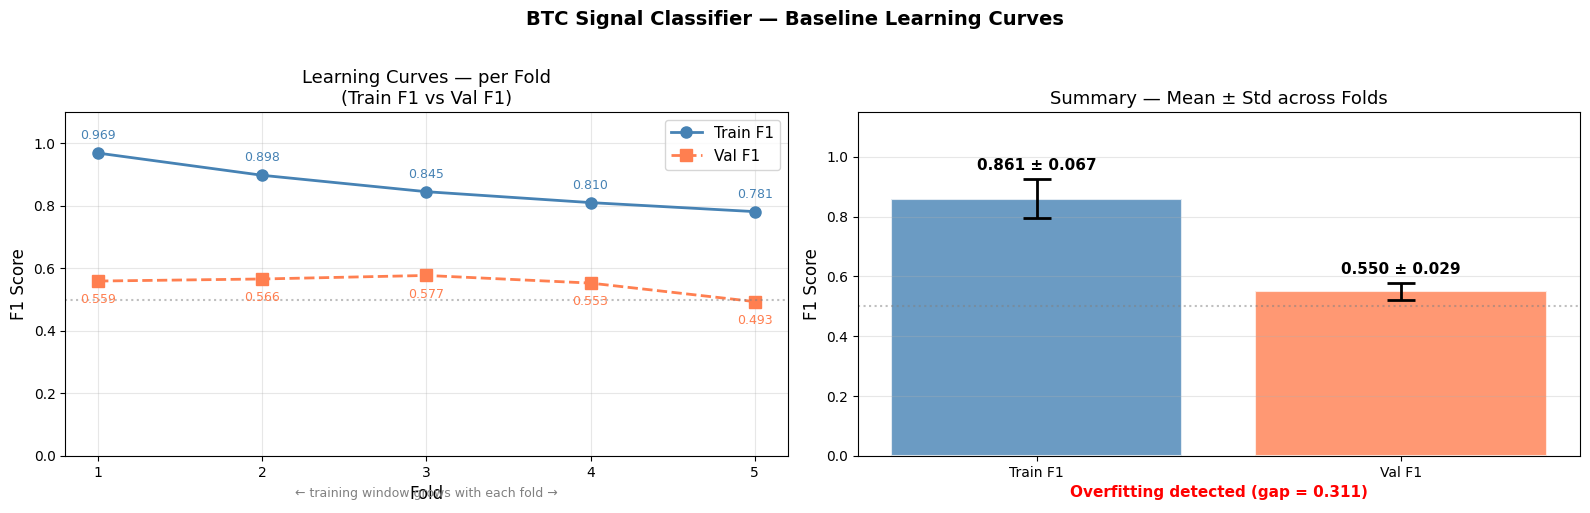

Train-Val gap: 0.311  →  Overfitting detected (gap = 0.311)


In [11]:
# Learning curves — per fold and summary

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

folds = list(range(1, len(fold_train_scores) + 1))


# ── Plot 1: Train F1 vs Val F1 per fold ────────────────────────────────────
ax1 = axes[0]

ax1.plot(folds, fold_train_scores,
         'o-', color='steelblue', linewidth=2, markersize=8, label='Train F1')
ax1.plot(folds, fold_val_scores,
         's--', color='coral', linewidth=2, markersize=8, label='Val F1')

for i, (tr, va) in enumerate(zip(fold_train_scores, fold_val_scores)):
    ax1.annotate(f'{tr:.3f}', (i + 1, tr),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, color='steelblue')
    ax1.annotate(f'{va:.3f}', (i + 1, va),
                 textcoords='offset points', xytext=(0, -16),
                 ha='center', fontsize=9, color='coral')

ax1.set_xlabel('Fold', fontsize=12)
ax1.set_ylabel('F1 Score', fontsize=12)
ax1.set_title('Learning Curves — per Fold\n(Train F1 vs Val F1)', fontsize=13)
ax1.set_xticks(folds)
ax1.set_ylim(0, 1.1)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Random baseline')
ax1.annotate('← training window grows with each fold →',
             xy=(0.5, -0.12), xycoords='axes fraction',
             ha='center', fontsize=9, color='gray')


# ── Plot 2: Summary — mean ± std across folds ──────────────────────────────
ax2 = axes[1]

mean_train = np.mean(fold_train_scores)
std_train  = np.std(fold_train_scores)
mean_val   = np.mean(fold_val_scores)
std_val    = np.std(fold_val_scores)

bars = ax2.bar(
    ['Train F1', 'Val F1'],
    [mean_train, mean_val],
    yerr=[std_train, std_val],
    color=['steelblue', 'coral'],
    alpha=0.8,
    capsize=10,
    edgecolor='white',
    linewidth=1.5,
    error_kw={'elinewidth': 2, 'ecolor': 'black', 'capthick': 2}
)

for bar, mean, std in zip(bars, [mean_train, mean_val], [std_train, std_val]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.02,
        f'{mean:.3f} ± {std:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('Summary — Mean ± Std across Folds', fontsize=13)
ax2.set_ylim(0, 1.15)
ax2.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
ax2.grid(True, alpha=0.3, axis='y')

# Overfitting verdict
gap = mean_train - mean_val
if gap > 0.15:
    verdict = f'Overfitting detected (gap = {gap:.3f})'
    color   = 'red'
elif gap > 0.05:
    verdict = f'Slight overfitting (gap = {gap:.3f})'
    color   = 'orange'
else:
    verdict = f'Good generalisation (gap = {gap:.3f})'
    color   = 'green'

ax2.text(0.5, -0.12, verdict,
         transform=ax2.transAxes,
         ha='center', fontsize=11, color=color, fontweight='bold')

plt.suptitle('BTC Signal Classifier — Baseline Learning Curves',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('learning_curves_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Train-Val gap: {gap:.3f}  →  {verdict}")

## 8 — Final Evaluation on Holdout Set

🔒 `X_holdout` is opened here for the first and only time.
Final model trained on full `X_train` using mean best iteration from CV.

In [12]:
# Train final model on full X_train, evaluate once on X_holdout
# Previous: no holdout — no genuinely unseen final evaluation
# Now:      pipe.fit(X_train) → pipe.predict(X_holdout) — once, at the end

print("Training final model on full X_train...")
final_start = time.time()

#before:
#pipe.fit(X_train, y_train)

#now: Use mean best iteration from CV — avoids training all 1000 trees
#mean_best_iter = int(np.mean(best_iterations))
#print(f"Setting n_estimators = {mean_best_iter} (mean best iteration from CV folds)")

#pipe.set_params(model__n_estimators = mean_best_iter)
pipe.set_params(model__n_estimators = 300)
pipe.fit(X_train, y_train)

final_elapsed = time.time() - final_start
print(f"Final model training time: {final_elapsed:.1f}s")

# 🔒 First and only time X_holdout is used
#y_holdout_pred = pipe.predict(X_holdout) #no THRESHOLD
#now: incl Threshold
y_holdout_pred = (pipe.predict_proba(X_holdout)[:, 1] >= THRESHOLD).astype(int)

print("\n" + "=" * 60)
print("FINAL EVALUATION — HOLDOUT SET")
print("(never seen during Walk-Forward CV)")
print("=" * 60)
print(f"Holdout period: {X_holdout.index[0].date()}  →  {X_holdout.index[-1].date()}")
print(f"Holdout bars:   {len(X_holdout):,}")
print("=" * 60 + "\n")

print(classification_report(
    y_holdout,
    y_holdout_pred,
    target_names=['FLAT (0)', 'BUY (1)']
))

Training final model on full X_train...
Final model training time: 2.8s

FINAL EVALUATION — HOLDOUT SET
(never seen during Walk-Forward CV)
Holdout period: 2024-07-19  →  2026-03-07
Holdout bars:   14,309

              precision    recall  f1-score   support

    FLAT (0)       0.50      0.90      0.64      7005
     BUY (1)       0.56      0.13      0.21      7304

    accuracy                           0.50     14309
   macro avg       0.53      0.51      0.42     14309
weighted avg       0.53      0.50      0.42     14309



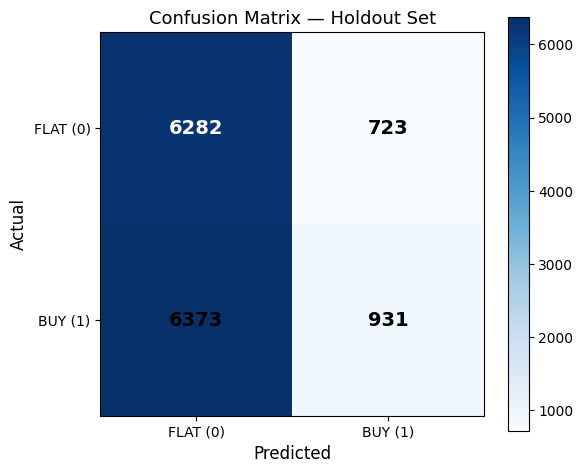

In [13]:
# Confusion Matrix — Holdout Set

cm = confusion_matrix(y_holdout, y_holdout_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

tick_marks = [0, 1]
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(['FLAT (0)', 'BUY (1)'])
ax.set_yticklabels(['FLAT (0)', 'BUY (1)'])

for i in range(2):
    for j in range(2):
        ax.text(
            j, i, str(cm[i, j]),
            ha='center', va='center',
            color='white' if (i == 0 and j == 0) else 'black',
            fontsize=14, fontweight='bold'
        )

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Holdout Set', fontsize=13)
plt.tight_layout()
#plt.savefig('confusion_matrix_holdout.png', dpi=150, bbox_inches='tight')
plt.show()

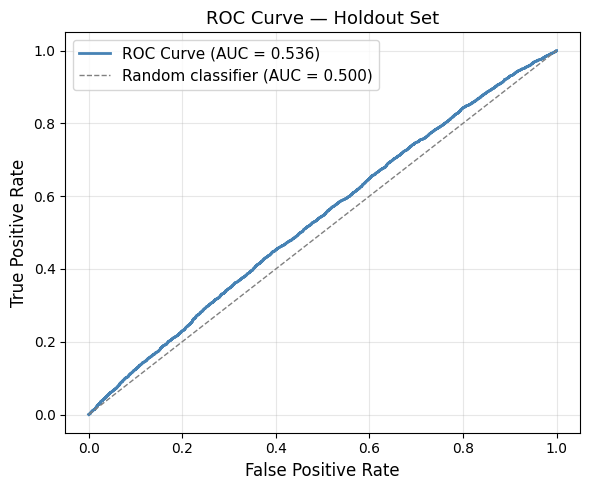

AUC Score: 0.536
AUC = 0.5 → random classifier
AUC = 1.0 → perfect classifier


In [14]:
# ROC Curve — Holdout Set
from sklearn.metrics import roc_curve, roc_auc_score

# predict_proba gives probability scores, not hard labels
# we use the probability of BUY (class 1) for the ROC curve
y_holdout_proba = pipe.predict_proba(X_holdout)[:, 1]

fpr, tpr, _ = roc_curve(y_holdout, y_holdout_proba)
auc = roc_auc_score(y_holdout, y_holdout_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'ROC Curve (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1, label='Random classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Holdout Set', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('roc_curve_holdout.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC Score: {auc:.3f}")
print("AUC = 0.5 → random classifier")
print("AUC = 1.0 → perfect classifier")

In [15]:
# CV vs Holdout comparison — sanity check
# Holdout score is almost always lower than CV score
# A large gap between the two indicates overfitting to the training period

holdout_prec = precision_score(y_holdout, y_holdout_pred, zero_division=0)
holdout_rec  = recall_score(y_holdout, y_holdout_pred, zero_division=0)
holdout_f1   = f1_score(y_holdout, y_holdout_pred, zero_division=0)

print("CV vs Holdout — Sanity Check")
print("=" * 50)
print(f"Mean CV Val F1:     {np.mean(fold_val_scores):.3f} ± {np.std(fold_val_scores):.3f}")
print(f"Holdout F1:         {holdout_f1:.3f}")
print()
print(f"Mean CV Precision:  {metrics_df['Val Precision'].mean():.3f}")
print(f"Holdout Precision:  {holdout_prec:.3f}")
print()
cv_holdout_gap = np.mean(fold_val_scores) - holdout_f1
print(f"CV → Holdout gap:   {cv_holdout_gap:.3f}")
if cv_holdout_gap > 0.10:
    print("⚠️  Large gap — model may be overfitting to the 2018-2024 period")
else:
    print("✅  Small gap — model generalises reasonably across time periods")

CV vs Holdout — Sanity Check
Mean CV Val F1:     0.550 ± 0.029
Holdout F1:         0.208

Mean CV Precision:  0.550
Holdout Precision:  0.563

CV → Holdout gap:   0.342
⚠️  Large gap — model may be overfitting to the 2018-2024 period


## 9 — v2.2 Regime Filter Only

Bull-regime bars only: SMA50 > SMA200 and ADX > 25.
Label unchanged: `forward_return > 0`.

In [16]:
# Regime as label modifier — not a row filter
# Bear-regime bars stay in training as FLAT=0
df['y_v22'] = (
    (df['forward_return'] > 0) & (df['regime'] == 1)
).astype(int)

print(f"Total bars:       {len(df):,}")
print(f"BUY ratio:        {df['y_v22'].mean():.1%}")

X_v22 = df[X_cols]
y_v22 = df['y_v22']

split_idx_v22  = int(len(X_v22) * 0.80)
X_train_v22    = X_v22.iloc[:split_idx_v22]
X_holdout_v22  = X_v22.iloc[split_idx_v22:]
y_train_v22    = y_v22.iloc[:split_idx_v22]
y_holdout_v22  = y_v22.iloc[split_idx_v22:]

# scale_pos_weight
n_flat_v22       = (y_train_v22 == 0).sum()
n_buy_v22        = (y_train_v22 == 1).sum()
spw_v22          = n_flat_v22 / n_buy_v22

print(f"\nTrain bars: {len(X_train_v22):,} | Holdout bars: {len(X_holdout_v22):,}")
print(f"BUY ratio:  {y_train_v22.mean():.1%} | scale_pos_weight: {spw_v22:.2f}")

# Pipeline
pipe_v22 = Pipeline([
    ('model', LGBMClassifier(
        objective        = 'binary',
        boosting_type    = 'gbdt',
        n_estimators     = 300,
        learning_rate    = 0.05,
        num_leaves       = 31,
        feature_fraction = 0.8,
        bagging_fraction = 0.8,
        bagging_freq     = 5,
        scale_pos_weight = spw_v22,
        random_state     = 42,
        verbose          = -1
    ))
])

# Walk-Forward CV
tscv_v22 = TimeSeriesSplit(n_splits=5, gap=24)
fold_train_v22, fold_val_v22, best_iter_v22 = [], [], []

for fold, (train_idx, val_idx) in enumerate(tscv_v22.split(X_train_v22)):
    Xf_tr = X_train_v22.iloc[train_idx]
    yf_tr = y_train_v22.iloc[train_idx]
    Xf_va = X_train_v22.iloc[val_idx]
    yf_va = y_train_v22.iloc[val_idx]

    pipe_v22.fit(Xf_tr, yf_tr)

    #best_iter_v22.append(pipe_v22['model'].best_iteration_)
    fold_train_v22.append(f1_score(yf_tr, pipe_v22.predict(Xf_tr), zero_division=0))
    fold_val_v22.append(f1_score(yf_va, pipe_v22.predict(Xf_va), zero_division=0))
    #print(f"  Fold {fold+1} | Val F1: {fold_val_v22[-1]:.3f} | Best iter: {best_iter_v22[-1]}")
    print(f"  Fold {fold+1} | Val F1: {fold_val_v22[-1]:.3f}")

# Final model
#mean_best_v22 = int(np.mean(best_iter_v22))
# pipe_v22.set_params(model__n_estimators=mean_best_v22)
pipe_v22.set_params(model__n_estimators=300)
pipe_v22.fit(X_train_v22, y_train_v22)


#y_pred_v22   = pipe_v22.predict(X_holdout_v22)#no THRESHOLD
y_pred_v22   = (pipe_v22.predict_proba(X_holdout_v22)[:, 1] >= THRESHOLD).astype(int)
y_proba_v22  = pipe_v22.predict_proba(X_holdout_v22)[:, 1]

prec_v22 = precision_score(y_holdout_v22, y_pred_v22, zero_division=0)
f1_v22   = f1_score(y_holdout_v22, y_pred_v22, zero_division=0)
auc_v22  = roc_auc_score(y_holdout_v22, y_proba_v22)

print(f"\nMean Val F1:   {np.mean(fold_val_v22):.3f} ± {np.std(fold_val_v22):.3f}")
print(f"Train-Val gap: {np.mean(fold_train_v22) - np.mean(fold_val_v22):.3f}")
print(f"Holdout — Precision: {prec_v22:.3f} | F1: {f1_v22:.3f} | AUC: {auc_v22:.3f}")

Total bars:       71,545
BUY ratio:        15.5%

Train bars: 57,236 | Holdout bars: 14,309
BUY ratio:  15.6% | scale_pos_weight: 5.41
  Fold 1 | Val F1: 0.354
  Fold 2 | Val F1: 0.465
  Fold 3 | Val F1: 0.426
  Fold 4 | Val F1: 0.424
  Fold 5 | Val F1: 0.484

Mean Val F1:   0.431 ± 0.044
Train-Val gap: 0.332
Holdout — Precision: 0.369 | F1: 0.412 | AUC: 0.819


## 10 — v2.3 ATR Threshold Only

No regime filter. Label = `forward_return > k * ATR / Close`.
Tests whether ATR threshold alone improves signal quality.
k tested: 0.5, 1.0, 1.5

In [17]:
print("=" * 60)
print("v2.3 — ATR Threshold Only (no regime filter)")
print("=" * 60)

# Label distribution check — choose k where BUY ratio is 20-40%
print("Label distribution per k:")
for k in [0.5, 1.0, 1.5]:
    threshold = k * df['atr_14'] / df['Close']
    y_temp    = (df['forward_return'] > threshold).astype(int)
    print(f"  k={k:.1f} | BUY: {y_temp.mean():.1%} | FLAT: {1-y_temp.mean():.1%}")

# Set k based on distribution above
K_V23 = 0.5

print(f"\nSelected k = {K_V23}")
threshold_v23  = K_V23 * df['atr_14'] / df['Close']
df['y_v23']    = (df['forward_return'] > threshold_v23).astype(int)

X_v23 = df[X_cols]
y_v23 = df['y_v23']

split_idx_v23  = int(len(X_v23) * 0.80)
X_train_v23    = X_v23.iloc[:split_idx_v23]
X_holdout_v23  = X_v23.iloc[split_idx_v23:]
y_train_v23    = y_v23.iloc[:split_idx_v23]
y_holdout_v23  = y_v23.iloc[split_idx_v23:]

n_flat_v23     = (y_train_v23 == 0).sum()
n_buy_v23      = (y_train_v23 == 1).sum()
spw_v23        = n_flat_v23 / n_buy_v23

print(f"Train bars: {len(X_train_v23):,} | Holdout bars: {len(X_holdout_v23):,}")
print(f"BUY ratio:  {y_train_v23.mean():.1%} | scale_pos_weight: {spw_v23:.2f}")

pipe_v23 = Pipeline([
    ('model', LGBMClassifier(
        objective        = 'binary',
        boosting_type    = 'gbdt',
        n_estimators     = 300,
        learning_rate    = 0.05,
        num_leaves       = 31,
        feature_fraction = 0.8,
        bagging_fraction = 0.8,
        bagging_freq     = 5,
        scale_pos_weight = spw_v23,
       # is_unbalanced    = True, #added
        random_state     = 42,
        verbose          = -1
    ))
])

tscv_v23 = TimeSeriesSplit(n_splits=5, gap=24)
fold_train_v23, fold_val_v23, best_iter_v23 = [], [], []

for fold, (train_idx, val_idx) in enumerate(tscv_v23.split(X_train_v23)):
    Xf_tr = X_train_v23.iloc[train_idx]
    yf_tr = y_train_v23.iloc[train_idx]
    Xf_va = X_train_v23.iloc[val_idx]
    yf_va = y_train_v23.iloc[val_idx]

    #pipe_v23.fit(
    #    Xf_tr, yf_tr,
    #    model__eval_set  = [(Xf_va, yf_va)],
    #    model__callbacks = [
    #        lgb.early_stopping(stopping_rounds=50, verbose=False),
    #        lgb.log_evaluation(period=0)
    #    ]
    #)

    #New: no Early stopping
    pipe_v23.fit(Xf_tr, yf_tr)

    #best_iter_v23.append(pipe_v23['model'].best_iteration_)
    fold_train_v23.append(f1_score(yf_tr, pipe_v23.predict(Xf_tr), zero_division=0))
    fold_val_v23.append(f1_score(yf_va, pipe_v23.predict(Xf_va), zero_division=0))
    #print(f"  Fold {fold+1} | Val F1: {fold_val_v23[-1]:.3f} | Best iter: {best_iter_v23[-1]}")
    print(f"  Fold {fold+1} | Val F1: {fold_val_v23[-1]:.3f}")

#mean_best_v23 = int(np.mean(best_iter_v23))
#pipe_v23.set_params(model__n_estimators=mean_best_v23)
#pipe_v23.fit(X_train_v23, y_train_v23)

#new:
pipe_v23.set_params(model__n_estimators=300)
pipe_v23.fit(X_train_v23, y_train_v23)

#y_pred_v23  = pipe_v23.predict(X_holdout_v23)#no threshold
y_pred_v23  = (pipe_v23.predict_proba(X_holdout_v23)[:, 1] >= THRESHOLD).astype(int)
y_proba_v23 = pipe_v23.predict_proba(X_holdout_v23)[:, 1]

prec_v23 = precision_score(y_holdout_v23, y_pred_v23, zero_division=0)
f1_v23   = f1_score(y_holdout_v23, y_pred_v23, zero_division=0)
auc_v23  = roc_auc_score(y_holdout_v23, y_proba_v23)

print(f"\nMean Val F1:   {np.mean(fold_val_v23):.3f} ± {np.std(fold_val_v23):.3f}")
print(f"Train-Val gap: {np.mean(fold_train_v23) - np.mean(fold_val_v23):.3f}")
print(f"Holdout — Precision: {prec_v23:.3f} | F1: {f1_v23:.3f} | AUC: {auc_v23:.3f}")

v2.3 — ATR Threshold Only (no regime filter)
Label distribution per k:
  k=0.5 | BUY: 32.2% | FLAT: 67.8%
  k=1.0 | BUY: 19.0% | FLAT: 81.0%
  k=1.5 | BUY: 11.4% | FLAT: 88.6%

Selected k = 0.5
Train bars: 57,236 | Holdout bars: 14,309
BUY ratio:  31.8% | scale_pos_weight: 2.14
  Fold 1 | Val F1: 0.326
  Fold 2 | Val F1: 0.388
  Fold 3 | Val F1: 0.423
  Fold 4 | Val F1: 0.386
  Fold 5 | Val F1: 0.376

Mean Val F1:   0.380 ± 0.031
Train-Val gap: 0.434
Holdout — Precision: 0.412 | F1: 0.134 | AUC: 0.559


## 11 — v2.4 Regime + ATR Threshold

Bull-regime bars only AND ATR threshold label.
Best of both: clean regime + noise-filtered labels.

In [18]:
print("=" * 60)
print("v2.4 — Regime Filter + ATR Threshold")
print("=" * 60)

# Regime + ATR as label modifier — not a row filter
print(f"Total bars: {len(df):,}")

# Label distribution check
print("\nLabel distribution per k:")
for k in [0.5, 1.0, 1.5]:
    threshold = k * df['atr_14'] / df['Close']
    y_temp    = (
        (df['forward_return'] > threshold) & (df['regime'] == 1)
    ).astype(int)
    print(f"  k={k:.1f} | BUY: {y_temp.mean():.1%} | FLAT: {1-y_temp.mean():.1%}")

K_V24 = 0.5
print(f"\nSelected k = {K_V24}")
threshold_v24  = K_V24 * df['atr_14'] / df['Close']
df['y_v24']    = (
    (df['forward_return'] > threshold_v24) & (df['regime'] == 1)
).astype(int)

X_v24 = df[X_cols]
y_v24 = df['y_v24']

split_idx_v24  = int(len(X_v24) * 0.80)
X_train_v24    = X_v24.iloc[:split_idx_v24]
X_holdout_v24  = X_v24.iloc[split_idx_v24:]
y_train_v24    = y_v24.iloc[:split_idx_v24]
y_holdout_v24  = y_v24.iloc[split_idx_v24:]


n_flat_v24     = (y_train_v24 == 0).sum()
n_buy_v24      = (y_train_v24 == 1).sum()
spw_v24        = n_flat_v24 / n_buy_v24

print(f"Train bars: {len(X_train_v24):,} | Holdout bars: {len(X_holdout_v24):,}")
print(f"BUY ratio:  {y_train_v24.mean():.1%} | scale_pos_weight: {spw_v24:.2f}")

pipe_v24 = Pipeline([
    ('model', LGBMClassifier(
        objective        = 'binary',
        boosting_type    = 'gbdt',
        n_estimators     = 300,
        learning_rate    = 0.05,
        num_leaves       = 31,
        feature_fraction = 0.8,
        bagging_fraction = 0.8,
        bagging_freq     = 5,
        scale_pos_weight = spw_v24,
       # is_unbalanced    = True, #added
        random_state     = 42,
        verbose          = -1
    ))
])

tscv_v24 = TimeSeriesSplit(n_splits=5, gap=24)
fold_train_v24, fold_val_v24, best_iter_v24 = [], [], []

for fold, (train_idx, val_idx) in enumerate(tscv_v24.split(X_train_v24)):
    Xf_tr = X_train_v24.iloc[train_idx]
    yf_tr = y_train_v24.iloc[train_idx]
    Xf_va = X_train_v24.iloc[val_idx]
    yf_va = y_train_v24.iloc[val_idx]

   # pipe_v24.fit(
   #     Xf_tr, yf_tr,
   #     model__eval_set  = [(Xf_va, yf_va)],
   #     model__callbacks = [
   #         lgb.early_stopping(stopping_rounds=50, verbose=False),
   #         lgb.log_evaluation(period=0)
   #     ]
   # )

    pipe_v24.fit(Xf_tr, yf_tr)

    #best_iter_v24.append(pipe_v24['model'].best_iteration_)
    fold_train_v24.append(f1_score(yf_tr, pipe_v24.predict(Xf_tr), zero_division=0))
    fold_val_v24.append(f1_score(yf_va, pipe_v24.predict(Xf_va), zero_division=0))
    #print(f"  Fold {fold+1} | Val F1: {fold_val_v24[-1]:.3f} | Best iter: {best_iter_v24[-1]}")
    print(f"  Fold {fold+1} | Val F1: {fold_val_v24[-1]:.3f}")

#mean_best_v24 = int(np.mean(best_iter_v24))
#pipe_v24.set_params(model__n_estimators=mean_best_v24)
#pipe_v24.fit(X_train_v24, y_train_v24)

pipe_v24.set_params(model__n_estimators=300)
pipe_v24.fit(X_train_v24, y_train_v24)

#y_pred_v24  = pipe_v24.predict(X_holdout_v24) #no threshold
y_pred_v24  = (pipe_v24.predict_proba(X_holdout_v24)[:, 1] >= THRESHOLD).astype(int)
y_proba_v24 = pipe_v24.predict_proba(X_holdout_v24)[:, 1]

prec_v24 = precision_score(y_holdout_v24, y_pred_v24, zero_division=0)
f1_v24   = f1_score(y_holdout_v24, y_pred_v24, zero_division=0)
auc_v24  = roc_auc_score(y_holdout_v24, y_proba_v24)

v2.4 — Regime Filter + ATR Threshold
Total bars: 71,545

Label distribution per k:
  k=0.5 | BUY: 9.8% | FLAT: 90.2%
  k=1.0 | BUY: 6.0% | FLAT: 94.0%
  k=1.5 | BUY: 3.9% | FLAT: 96.1%

Selected k = 0.5
Train bars: 57,236 | Holdout bars: 14,309
BUY ratio:  9.7% | scale_pos_weight: 9.34
  Fold 1 | Val F1: 0.140
  Fold 2 | Val F1: 0.319
  Fold 3 | Val F1: 0.264
  Fold 4 | Val F1: 0.265
  Fold 5 | Val F1: 0.322


## 12 — Comparison: All Four Variants

In [19]:
# ── Collect v2.1 metrics from existing variables ──────────────────────────
# v2.1 uses the variables already computed in Sections 5-8

prec_v21 = holdout_prec
f1_v21   = holdout_f1
auc_v21  = auc

fold_train_v21 = fold_train_scores
fold_val_v21   = fold_val_scores

# ── Comparison table ───────────────────────────────────────────────────────
comparison = pd.DataFrame([
    {
        'Variant'        : 'v2.1 Baseline',
        'Regime Filter'  : 'No',
        'ATR Threshold'  : 'No',
        'Train bars'     : len(X_train),
        'Mean Val F1'    : round(np.mean(fold_val_v21), 3),
        'Train-Val Gap'  : round(np.mean(fold_train_v21) - np.mean(fold_val_v21), 3),
        'Holdout Prec'   : round(prec_v21, 3),
        'Holdout F1'     : round(f1_v21, 3),
        'Holdout AUC'    : round(auc_v21, 3),
    },
    {
        'Variant'        : 'v2.2 Regime only',
        'Regime Filter'  : 'Yes',
        'ATR Threshold'  : 'No',
        'Train bars'     : len(X_train_v22),
        'Mean Val F1'    : round(np.mean(fold_val_v22), 3),
        'Train-Val Gap'  : round(np.mean(fold_train_v22) - np.mean(fold_val_v22), 3),
        'Holdout Prec'   : round(prec_v22, 3),
        'Holdout F1'     : round(f1_v22, 3),
        'Holdout AUC'    : round(auc_v22, 3),
    },
    {
        'Variant'        : 'v2.3 ATR only',
        'Regime Filter'  : 'No',
        'ATR Threshold'  : f'k={K_V23}',
        'Train bars'     : len(X_train_v23),
        'Mean Val F1'    : round(np.mean(fold_val_v23), 3),
        'Train-Val Gap'  : round(np.mean(fold_train_v23) - np.mean(fold_val_v23), 3),
        'Holdout Prec'   : round(prec_v23, 3),
        'Holdout F1'     : round(f1_v23, 3),
        'Holdout AUC'    : round(auc_v23, 3),
    },
    {
        'Variant'        : 'v2.4 Regime + ATR',
        'Regime Filter'  : 'Yes',
        'ATR Threshold'  : f'k={K_V24}',
        'Train bars'     : len(X_train_v24),
        'Mean Val F1'    : round(np.mean(fold_val_v24), 3),
        'Train-Val Gap'  : round(np.mean(fold_train_v24) - np.mean(fold_val_v24), 3),
        'Holdout Prec'   : round(prec_v24, 3),
        'Holdout F1'     : round(f1_v24, 3),
        'Holdout AUC'    : round(auc_v24, 3),
    },
]).set_index('Variant')

print("Comparison — All Four Variants")
print("=" * 75)
display(comparison)

best = comparison['Holdout Prec'].idxmax()
print(f"\nBest Holdout Precision: {best}")

Comparison — All Four Variants


,Regime Filter,ATR Threshold,Train bars,Mean Val F1,Train-Val Gap,Holdout Prec,Holdout F1,Holdout AUC
Variant,,,,,,,,
v2.1 Baseline,No,No,57236,0.550,0.311,0.563,0.208,0.536
v2.2 Regime only,Yes,No,57236,0.431,0.332,0.369,0.412,0.819
v2.3 ATR only,No,k=0.5,57236,0.380,0.434,0.412,0.134,0.559
v2.4 Regime + ATR,Yes,k=0.5,57236,0.262,0.446,0.247,0.258,0.797



Best Holdout Precision: v2.1 Baseline


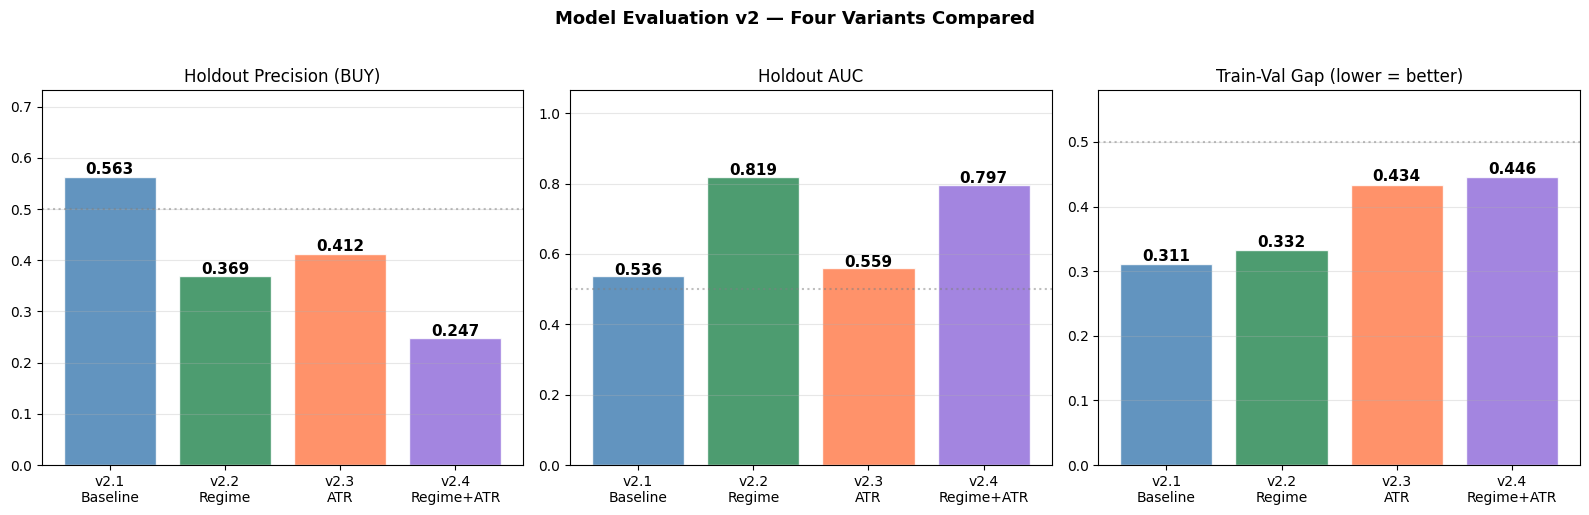

In [20]:
# ── Visual comparison ─────────────────────────────────────────────────────

variants = ['v2.1\nBaseline', 'v2.2\nRegime', 'v2.3\nATR', 'v2.4\nRegime+ATR']
colors   = ['steelblue', 'seagreen', 'coral', 'mediumpurple']

prec_all = [prec_v21, prec_v22, prec_v23, prec_v24]
auc_all  = [auc_v21,  auc_v22,  auc_v23,  auc_v24]
gap_all  = [
    round(np.mean(fold_train_v21) - np.mean(fold_val_v21), 3),
    round(np.mean(fold_train_v22) - np.mean(fold_val_v22), 3),
    round(np.mean(fold_train_v23) - np.mean(fold_val_v23), 3),
    round(np.mean(fold_train_v24) - np.mean(fold_val_v24), 3),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, values, title in zip(
    axes,
    [prec_all, auc_all, gap_all],
    ['Holdout Precision (BUY)', 'Holdout AUC', 'Train-Val Gap (lower = better)']
):
    bars = ax.bar(variants, values, color=colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', fontsize=11, fontweight='bold'
        )
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, max(values) * 1.3)
    ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Evaluation v2 — Four Variants Compared',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('variant_comparison_v32.png', dpi=150, bbox_inches='tight')
plt.show()